In [1]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from python_tsp.distances import euclidean_distance_matrix
from python_tsp.heuristics import solve_tsp_local_search
import time

import sys
sys.path.append('..')
from python.animation import *
from python.postprocess import *
sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


## Load data for correction

In [2]:
labels_to_correct_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/simplemax-tracking/c3_simplemax_tracking.slp'
labels_to_correct = sleap.load_file(labels_to_correct_path)
print(labels_to_correct)
all_tracked_points = get_all_tracked_points(labels_to_correct, reorder=True)
id_mapping = get_id_mapping_array(all_tracked_points)

Labels(labeled_frames=828, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (827, 17, 2)
Missing point count: 105
reorder_idx.shape: (17,)


## Load corrected data (ground truth)

In [3]:
corrected_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/simplemax-tracking/c3_simplemax_tracking_corrected.slp'
corrected_labels = sleap.load_file(corrected_labels_path)
print(corrected_labels)
all_tracked_points_corrected = get_all_tracked_points(corrected_labels, reorder=True)
id_mapping_corrected = get_id_mapping_array(all_tracked_points_corrected)

Labels(labeled_frames=828, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (827, 17, 2)
Missing point count: 105
reorder_idx.shape: (17,)


## Candidates

### c1: center angle-based polygon construction

Algorithm:
1. for each frame:
    1. calculate the center position by averaging all point coordinates 
    2. for each point:
        1. calculate the angle between this point and the center position
    3. find the polygon order by sorting the angles 
    4. shift/rotate the polygon order to maximally align with the order from the previous frame 
    5. for each point:
        1. if the order from the latter from is inconsistent with the previous frame, correct it by assigning the same identity from the previous frame 

Notes:
- this is extremely sensitive to mispredicted points -> use a hard threshold to remove points with predicted score < 0.4?
- add old/new labels when rendering animations

In [7]:
(labels_to_correct.labeled_frames[1].instances[0])

PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/full_video_1_c3.mp4, shape=(828, 170, 174, 1), backend=MediaVideo), frame_idx=1, points=[tb1_node: (106.4, 28.5, 1.00)], score=0.91, track=Track(spawned_on=0, name='track_0'), tracking_score=-0.02)

In [8]:
def find_best_roll(curr_frame_indices: np.ndarray, prev_frame_indices: np.ndarray) -> int:
    """
    Find the optimal roll shift that maximizes alignment between two index arrays
    
    Args:
        curr_frame_indices: array of current frame indices
        prev_frame_indices: array of previous frame indices
        
    Returns:
        best_shift: integer shift that maximizes alignment
    """
    if np.array_equal(curr_frame_indices, prev_frame_indices):
        return 0
    n = len(curr_frame_indices)
    max_key = lambda n: np.sum(np.roll(curr_frame_indices, n) == prev_frame_indices)
    return max(range(n), key=max_key)

def get_corrected_coords(all_tracked_points, id_mapping):
    corrected_coords = all_tracked_points.copy()
    for frame_idx in range(1, all_tracked_points.shape[0]):
        corrected_coords[frame_idx] = all_tracked_points[frame_idx][id_mapping[frame_idx]]
    return corrected_coords

def polygon_correction(labels, polygon_constructor, mins_score=0.4):
    all_tracked_points = get_all_tracked_points(labels, reorder=True, min_score=mins_score)
    id_mapping = get_id_mapping_array(all_tracked_points)
    id_mapping = id_mapping.copy()
    frame_cnt = all_tracked_points.shape[0]
    idx_range = np.arange(all_tracked_points.shape[1])
    for frame_idx in range(1, frame_cnt):
        polygon_order = polygon_constructor(all_tracked_points[frame_idx])
        prev_frame_indices = id_mapping[frame_idx-1]
        best_shift = find_best_roll(polygon_order, prev_frame_indices)
        shifted_indices = np.roll(polygon_order, best_shift)        
        id_mapping[frame_idx] = idx_range[shifted_indices]
    corrected_coords = get_corrected_coords(all_tracked_points, id_mapping)
    return corrected_coords


In [19]:
def c1_correction(labels, mins_score=0.4):
    all_tracked_points = get_all_tracked_points(labels, reorder=True, min_score=mins_score)
    id_mapping = get_id_mapping_array(all_tracked_points)
    id_mapping = id_mapping.copy()
    frame_cnt = all_tracked_points.shape[0]
    idx_range = np.arange(all_tracked_points.shape[1])
    for frame_idx in range(1, frame_cnt):
        center_pos = np.mean(all_tracked_points[frame_idx], axis=0)
        coord_diff = all_tracked_points[frame_idx] - center_pos
        angles = np.arctan2(coord_diff[:, 1], coord_diff[:, 0])
        sorted_indices = np.argsort(angles)
        prev_frame_indices = id_mapping[frame_idx-1]
        best_shift = find_best_roll(sorted_indices, prev_frame_indices)
        shifted_indices = np.roll(sorted_indices, best_shift)
        # correction_cnt = np.sum(id_mapping[frame_idx] != id_mapping[frame_idx-1])
        correction_cnt = np.sum(id_mapping[frame_idx] != idx_range[shifted_indices])
        if correction_cnt > 0:
            print(f"============================== Frame {frame_idx} ==============================")
            print(f"Center position:    {center_pos}")
            print(f"Sorted indices:     {sorted_indices}")
            print(f"Prev frame indices: {prev_frame_indices}")
            print(f"Best shift: {best_shift}")
            print(f"Correction count: {correction_cnt}")
            if best_shift != 0:
                print(f'Shifted indices:    {shifted_indices}')
        id_mapping[frame_idx] = idx_range[shifted_indices]
    corrected_coords = get_corrected_coords(all_tracked_points, id_mapping)
    return corrected_coords

def get_corrected_coords(all_tracked_points, id_mapping):
    corrected_coords = all_tracked_points.copy()
    for frame_idx in range(1, all_tracked_points.shape[0]):
        corrected_coords[frame_idx] = all_tracked_points[frame_idx][id_mapping[frame_idx]]
    return corrected_coords

In [20]:
c1_corrected_coords = c1_correction(labels_to_correct, mins_score=0.4)

all_tracked_points shape: (827, 17, 2)
Missing point count: 116
reorder_idx.shape: (17,)
============================== Frame 196 ==============================
Center position:    [88.93058081 87.11877823]
Sorted indices:     [ 0  1  2  3  4  5  6  8  7  9 10 11 12 13 14 15 16]
Prev frame indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Best shift: 0
Correction count: 2
============================== Frame 197 ==============================
Center position:    [88.64236259 84.23020935]
Sorted indices:     [ 0  1  2  3  4  6  5  7  8  9 10 11 12 13 14 15 16]
Prev frame indices: [ 0  1  2  3  4  5  6  8  7  9 10 11 12 13 14 15 16]
Best shift: 0
Correction count: 2
============================== Frame 198 ==============================
Center position:    [88.39410816 84.56006892]
Sorted indices:     [16  0  1  2  3  4  6  5  7  8  9 10 11 12 13 14 15]
Prev frame indices: [ 0  1  2  3  4  6  5  7  8  9 10 11 12 13 14 15 16]
Best shift: 16
Correction count: 2
Shifted indices:

In [23]:
# help(labels_to_correct.video)
labels_to_correct.video.get_frame(1).shape

(170, 174, 1)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/c3_c1_corrected_bg_v2.mp4
Animation saved to /home/mingxiao/Desktop/animation/c3_c1_corrected_bg_v2.mp4


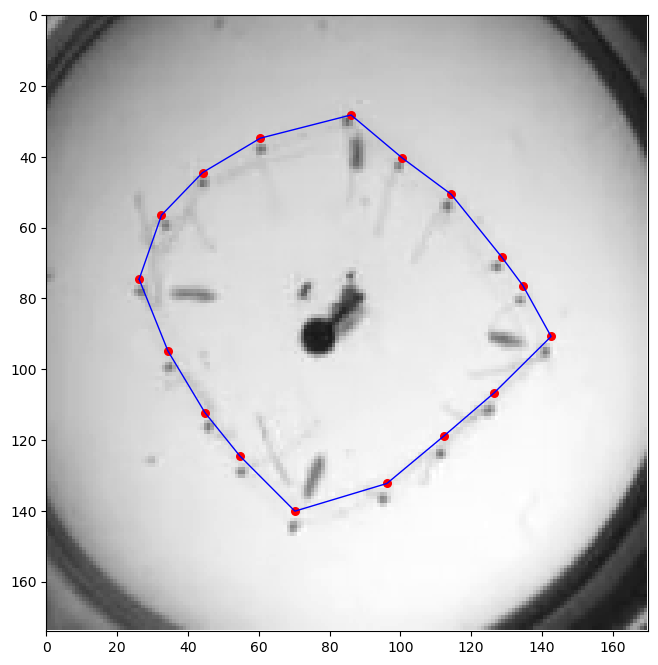

In [ ]:
# takes about twice the original video time to render (for 30-sec video)
corrected_animation_path = '/home/mingxiao/Desktop/animation/c3_c1_corrected_bg_v2.mp4'
frame_cnt, x, y = labels_to_correct.video.shape[:3]
get_animation_from_tracked_points(c1_corrected_coords, x, y, 
                                  output_path=corrected_animation_path, 
                                  bg_video=labels_to_correct.video, 
                                  bg_video_start_idx=1)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/c3_c1_corrected_manual.mp4
Animation saved to /home/mingxiao/Desktop/animation/c3_c1_corrected_manual.mp4


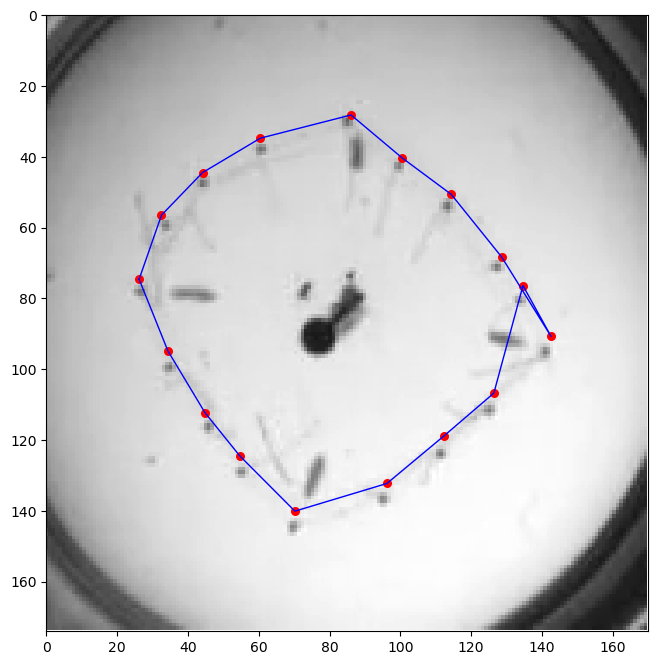

In [28]:
corrected_animation_path = '/home/mingxiao/Desktop/animation/c3_c1_corrected_manual.mp4'
frame_cnt, x, y = labels_to_correct.video.shape[:3]
get_animation_from_tracked_points(all_tracked_points_corrected, x, y, 
                                  output_path=corrected_animation_path, 
                                  bg_video=labels_to_correct.video, 
                                  bg_video_start_idx=1)

In [17]:
np.sum(c1_corrected_coords != all_tracked_points_corrected) / 2 

631.0

Total number of differences: 4163

Differences per point:
Point 0: 311 differences
Point 1: 89 differences
Point 2: 88 differences
Point 3: 630 differences
Point 4: 628 differences
Point 5: 34 differences
Point 6: 596 differences
Point 7: 526 differences
Point 8: 347 differences
Point 9: 604 differences
Point 10: 0 differences
Point 11: 0 differences
Point 12: 0 differences
Point 13: 0 differences
Point 14: 0 differences
Point 15: 0 differences
Point 16: 310 differences


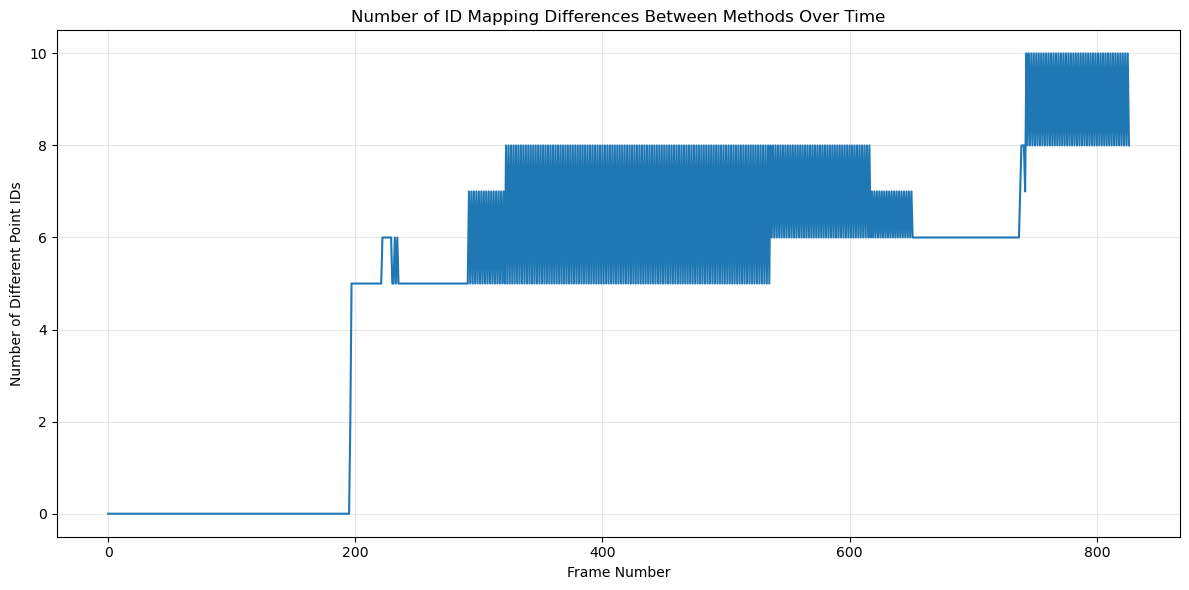

In [34]:
# Count total differences
differences = np.sum(c1_corrected_mapping != id_mapping_corrected)
print(f"Total number of differences: {differences}")

# Count differences per point
differences_per_point = np.sum(c1_corrected_mapping != id_mapping_corrected, axis=0)
print("\nDifferences per point:")
for point_idx, diff_count in enumerate(differences_per_point):
    print(f"Point {point_idx}: {diff_count} differences")

# Count differences per frame
differences_per_frame = np.sum(c1_corrected_mapping != id_mapping_corrected, axis=1)

# Plot differences over time
plt.figure(figsize=(12, 6))
plt.plot(differences_per_frame)
plt.xlabel('Frame Number')
plt.ylabel('Number of Different Point IDs')
plt.title('Number of ID Mapping Differences Between Methods Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### c2: shortest path-based polygon construction

In [34]:
def compute_total_length(points, path):
    total = 0.0
    N = len(path)
    for i in range(N):
        a = path[i]
        b = path[(i + 1) % N]
        total += np.linalg.norm(points[a] - points[b])
    return total

def nearest_neighbor_path(points):
    N = points.shape[0]
    if N == 0:
        return []
    start = np.lexsort((points[:, 1], points[:, 0]))[0]
    path = [start]
    visited = set([start])
    for _ in range(N - 1):
        current = path[-1]
        min_dist = np.inf
        next_point = -1
        for i in range(N):
            if i not in visited:
                dist = np.linalg.norm(points[current] - points[i])
                if dist < min_dist:
                    min_dist = dist
                    next_point = i
        path.append(next_point)
        visited.add(next_point)
    return path

def two_opt(points, path):
    path = path.copy()
    N = len(path)
    best_length = compute_total_length(points, path)
    improved = True
    while improved:
        improved = False
        for i in range(N):
            for j in range(i + 1, N):
                new_path = path.copy()
                new_path[i + 1:j + 1] = new_path[j:i:-1]
                new_length = compute_total_length(points, new_path)
                if new_length < best_length:
                    path = new_path
                    best_length = new_length
                    improved = True
                    break
            if improved:
                break
    return path

def od3(all_tracked_points):
    points = all_tracked_points
    N = points.shape[0]
    if N <= 2:
        return list(range(N))
    initial_path = nearest_neighbor_path(points)
    optimized_path = two_opt(points, initial_path)
    return optimized_path

In [31]:
def od1(points: np.ndarray) -> np.ndarray:
    """
    Find order of points to form a polygon with minimum total edge length
    
    Args:
        points: (N,2) array of point coordinates
        
    Returns:
        order: array of indices giving the order to connect points
    """
    N = len(points)
    if N < 3:
        return np.arange(N)
        
    # Start with first point
    order = [0]
    unvisited = set(range(1, N))
    
    # Find nearest unvisited neighbor until all points are used
    while unvisited:
        curr = order[-1]
        # Get distances from current point to all unvisited points
        distances = [(np.sum((points[curr] - points[i])**2), i) for i in unvisited]
        # Add closest unvisited point
        _, next_idx = min(distances)
        order.append(next_idx)
        unvisited.remove(next_idx)
    
    return np.array(order)

In [43]:
def nearest_neighbor_path(points):
    N = points.shape[0]
    if N == 0:
        return []
    start = np.lexsort((points[:, 1], points[:, 0]))[0]
    path = [start]
    visited = set([start])
    for _ in range(N - 1):
        current = path[-1]
        min_dist = np.inf
        next_point = -1
        for i in range(N):
            if i not in visited:
                dist = np.linalg.norm(points[current] - points[i])
                if dist < min_dist:
                    min_dist = dist
                    next_point = i
        path.append(next_point)
        visited.add(next_point)
    return path

def od2(all_tracked_points):
    points = all_tracked_points
    if len(points) <= 2:
        return list(range(len(points)))
    initial_permutation = nearest_neighbor_path(points)
    distance_matrix = euclidean_distance_matrix(points)
    permutation, _ = solve_tsp_local_search(distance_matrix, x0=initial_permutation)
    return permutation

In [45]:
# Example usage
all_tracked_points = np.random.rand(10, 2)  # Example set of points
p1 = od1(all_tracked_points)
print("Order of indices to connect the points:", p1)
p2 = od2(all_tracked_points)
print("Order of indices to connect the points:", p2)
p3 = od3(all_tracked_points)
print("Order of indices to connect the points:", p3)


Order of indices to connect the points: [0 3 8 7 1 4 9 5 6 2]
Order of indices to connect the points: [0, 3, 7, 1, 4, 2, 9, 5, 6, 8]
Order of indices to connect the points: [0, 3, 7, 1, 4, 2, 9, 5, 6, 8]


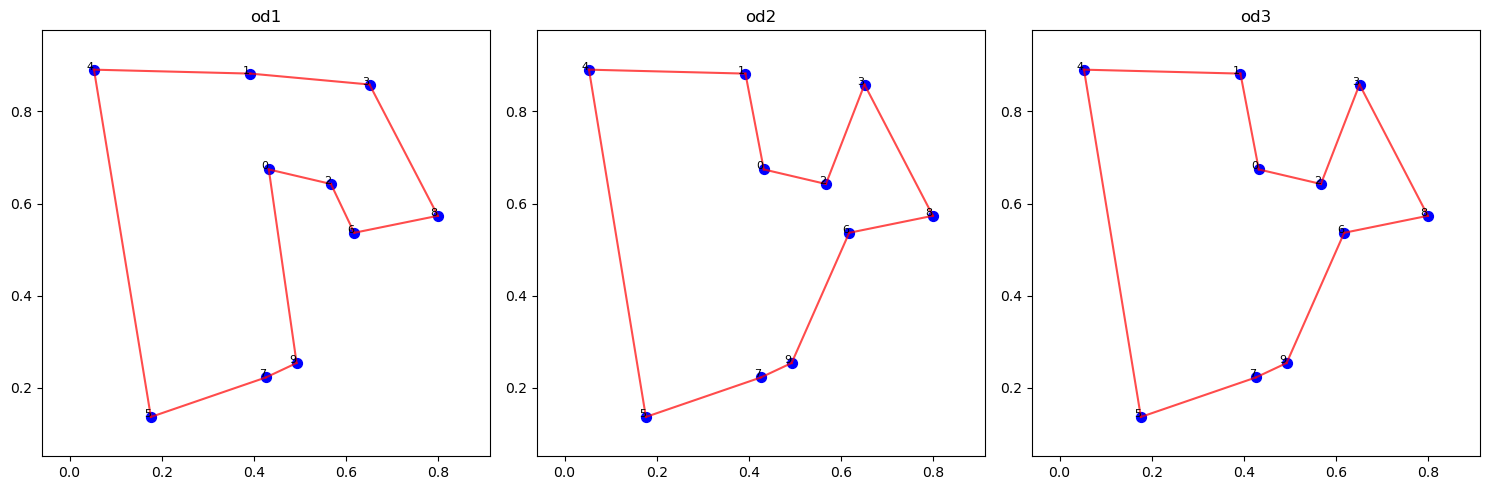


Total edge lengths:
od1: 2.9
od2: 2.8
od3: 2.8


In [53]:
def plot_polygon(points, order, ax, title):
    """Helper function to plot a polygon with given point order"""
    # Plot points
    ax.scatter(points[:, 0], points[:, 1], c='blue', s=50)
    
    # Plot edges connecting points in order
    for i in range(len(order)):
        start = points[order[i]]
        end = points[order[(i + 1) % len(order)]]
        ax.plot([start[0], end[0]], [start[1], end[1]], 'r-', alpha=0.7)
        
        # Add point indices as labels
        ax.text(points[order[i], 0], points[order[i], 1], 
                str(order[i]), fontsize=8, ha='right')
    
    ax.set_title(title)
    ax.axis('equal')

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Get frame points to test
frame_idx = 298  # Use first frame from stable ranges
frame_points = c1_corrected_coords[frame_idx]
frame_points = np.random.rand(10, 2)

# Plot original order
p1 = od1(frame_points)
plot_polygon(frame_points, p1, ax1, 'od1')

# Plot angle-based order
p2 = od2(frame_points)
plot_polygon(frame_points, p2, ax2, 'od2')

# Plot shortest-path order
p3 = od3(frame_points)
plot_polygon(frame_points, p3, ax3, 'od3')

plt.tight_layout()
plt.show()

# Print total edge lengths for comparison
def get_total_edge_length(points, order):
    total = 0
    for i in range(len(order)):
        start = points[order[i]]
        end = points[order[(i + 1) % len(order)]]
        total += np.sqrt(np.sum((end - start)**2))
    return total

print("\nTotal edge lengths:")
print(f"od1: {get_total_edge_length(frame_points, p1):.1f}")
print(f"od2: {get_total_edge_length(frame_points, p2):.1f}")
print(f"od3: {get_total_edge_length(frame_points, p3):.1f}")

In [ ]:
def c2_correction(labels, mins_score=0.4):
    all_tracked_points = get_all_tracked_points(labels, reorder=True, min_score=mins_score)
    id_mapping = get_id_mapping_array(all_tracked_points)
    id_mapping = id_mapping.copy()
    frame_cnt = all_tracked_points.shape[0]
    idx_range = np.arange(all_tracked_points.shape[1])
    for frame_idx in range(1, frame_cnt):
        center_pos = np.mean(all_tracked_points[frame_idx], axis=0)
        coord_diff = all_tracked_points[frame_idx] - center_pos
        angles = np.arctan2(coord_diff[:, 1], coord_diff[:, 0])
        sorted_indices = np.argsort(angles)
        prev_frame_indices = id_mapping[frame_idx-1]
        best_shift = find_best_roll(sorted_indices, prev_frame_indices)
        shifted_indices = np.roll(sorted_indices, best_shift)
        # correction_cnt = np.sum(id_mapping[frame_idx] != id_mapping[frame_idx-1])
        correction_cnt = np.sum(id_mapping[frame_idx] != idx_range[shifted_indices])
        if correction_cnt > 0:
            print(f"============================== Frame {frame_idx} ==============================")
            print(f"Center position:    {center_pos}")
            print(f"Sorted indices:     {sorted_indices}")
            print(f"Prev frame indices: {prev_frame_indices}")
            print(f"Best shift: {best_shift}")
            print(f"Correction count: {correction_cnt}")
            if best_shift != 0:
                print(f'Shifted indices:    {shifted_indices}')
        id_mapping[frame_idx] = idx_range[shifted_indices]
    corrected_coords = get_corrected_coords(all_tracked_points, id_mapping)
    return corrected_coords

### c3: displacement/nn distance-based swap detection

### c4: radial/tangential velocity-based swap detection

## Polygon-based correction

### Contestants

In [2]:
def find_best_roll(curr_frame_indices: np.ndarray, prev_frame_indices: np.ndarray) -> int:
    """
    Find the optimal roll shift that maximizes alignment between two index arrays
    
    Args:
        curr_frame_indices: array of current frame indices
        prev_frame_indices: array of previous frame indices
        
    Returns:
        best_shift: integer shift that maximizes alignment
    """
    if np.array_equal(curr_frame_indices, prev_frame_indices):
        return 0
    n = len(curr_frame_indices)
    max_key = lambda n: np.sum(np.roll(curr_frame_indices, n) == prev_frame_indices)
    return max(range(n), key=max_key)

def get_corrected_coords(all_tracked_points, id_mapping):
    corrected_coords = all_tracked_points.copy()
    for frame_idx in range(1, all_tracked_points.shape[0]):
        corrected_coords[frame_idx] = all_tracked_points[frame_idx][id_mapping[frame_idx]]
    return corrected_coords

def polygon_correction(labels, polygon_constructor, mins_score=0.4):
    all_tracked_points = get_all_tracked_points(labels, reorder=True, min_score=mins_score)
    id_mapping = get_id_mapping_array(all_tracked_points)
    id_mapping = id_mapping.copy()
    frame_cnt = all_tracked_points.shape[0]
    idx_range = np.arange(all_tracked_points.shape[1])
    
    for frame_idx in range(1, frame_cnt):
        polygon_order = polygon_constructor(all_tracked_points[frame_idx])
        prev_frame_indices = id_mapping[frame_idx-1]
        best_shift = find_best_roll(polygon_order, prev_frame_indices)
        shifted_indices = np.roll(polygon_order, best_shift)        
        id_mapping[frame_idx] = idx_range[shifted_indices]
        
    corrected_coords = get_corrected_coords(all_tracked_points, id_mapping)
    return corrected_coords


#### p1: angle-based

In [3]:
def poly_1(points):
    center_pos = np.mean(points, axis=0)
    coord_diff = points - center_pos
    angles = np.arctan2(coord_diff[:, 1], coord_diff[:, 0])
    sorted_indices = np.argsort(angles)
    return sorted_indices

#### p2: shortest path: nearest neighbor initialization + 2-opt optimization

In [4]:
def compute_total_length(points, path):
    total = 0.0
    N = len(path)
    for i in range(N):
        a = path[i]
        b = path[(i + 1) % N]
        total += np.linalg.norm(points[a] - points[b])
    return total

def nearest_neighbor_path(points):
    N = points.shape[0]
    if N == 0:
        return []
    start = np.lexsort((points[:, 1], points[:, 0]))[0]
    path = [start]
    visited = set([start])
    for _ in range(N - 1):
        current = path[-1]
        min_dist = np.inf
        next_point = -1
        for i in range(N):
            if i not in visited:
                dist = np.linalg.norm(points[current] - points[i])
                if dist < min_dist:
                    min_dist = dist
                    next_point = i
        path.append(next_point)
        visited.add(next_point)
    return path

def two_opt(points, path):
    path = path.copy()
    N = len(path)
    best_length = compute_total_length(points, path)
    improved = True
    while improved:
        improved = False
        for i in range(N):
            for j in range(i + 1, N):
                new_path = path.copy()
                new_path[i + 1:j + 1] = new_path[j:i:-1]
                new_length = compute_total_length(points, new_path)
                if new_length < best_length:
                    path = new_path
                    best_length = new_length
                    improved = True
                    break
            if improved:
                break
    return path

def poly_2(all_tracked_points):
    points = all_tracked_points
    N = points.shape[0]
    if N <= 2:
        return list(range(N))
    initial_path = nearest_neighbor_path(points)
    optimized_path = two_opt(points, initial_path)
    return optimized_path

#### p3: shortest path: `tsp-python` library

In [5]:
def poly_3(all_tracked_points):
    points = all_tracked_points
    if len(points) <= 2:
        return list(range(len(points)))
    initial_permutation = nearest_neighbor_path(points)
    distance_matrix = euclidean_distance_matrix(points)
    permutation, _ = solve_tsp_local_search(distance_matrix, x0=initial_permutation)
    return permutation

### Round 1: random polygon construction

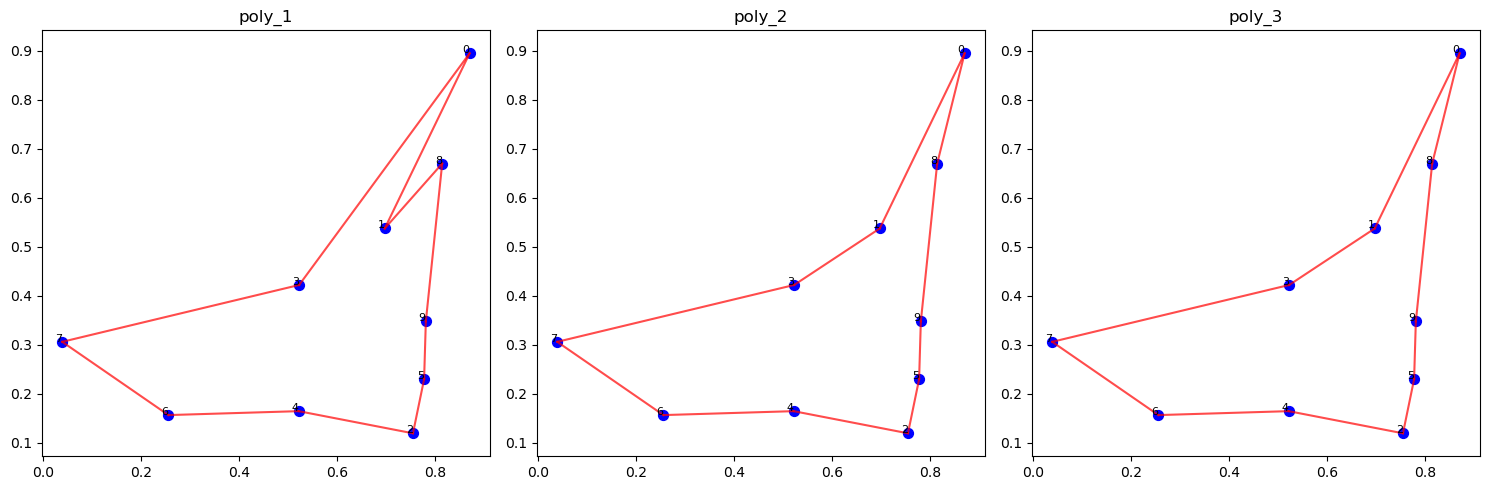


Total edge lengths:
poly_1: 2.982
poly_2: 2.659
poly_3: 2.659


In [25]:
def plot_some_polygons(points: np.ndarray, poly_constructors: list):
    polygons = [poly_constructor(points) for poly_constructor in poly_constructors]
    _, axs = plt.subplots(1, len(polygons), figsize=(15, 5))
    for i, order in enumerate(polygons):
        plot_polygon(points, order, axs[i], f'poly_{i+1}')
    plt.tight_layout()
    plt.show()
    
    print("\nTotal edge lengths:")
    for i, order in enumerate(polygons):
        print(f"poly_{i+1}: {get_total_edge_length(points, order):.3f}")

plot_some_polygons(frame_points, [poly_1, poly_2, poly_3])


### Round 2: 30-sec video correction

In [19]:
import time
methods = [(f'poly_{i}', eval(f'poly_{i}')) for i in range(1, 4)]
all_corrected_coords = []

for name, method in methods:
    start_time = time.time()
    corrected_coords = polygon_correction(labels_to_correct, method, mins_score=0.4)
    end_time = time.time()
    all_corrected_coords.append(corrected_coords)
    print(f"===== {name} execution time: {end_time - start_time:.2f} seconds ======\n")

all_tracked_points shape: (827, 17, 2)
Missing point count: 116
reorder_idx.shape: (17,)
===== poly_1 execution time: 1.06 seconds ======

all_tracked_points shape: (827, 17, 2)
Missing point count: 116
reorder_idx.shape: (17,)
===== poly_2 execution time: 10.81 seconds ======

all_tracked_points shape: (827, 17, 2)
Missing point count: 116
reorder_idx.shape: (17,)
===== poly_3 execution time: 2.84 seconds ======



INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 2400x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/c3_poly_corrected.mp4
Animation saved to /home/mingxiao/Desktop/animation/c3_poly_corrected.mp4


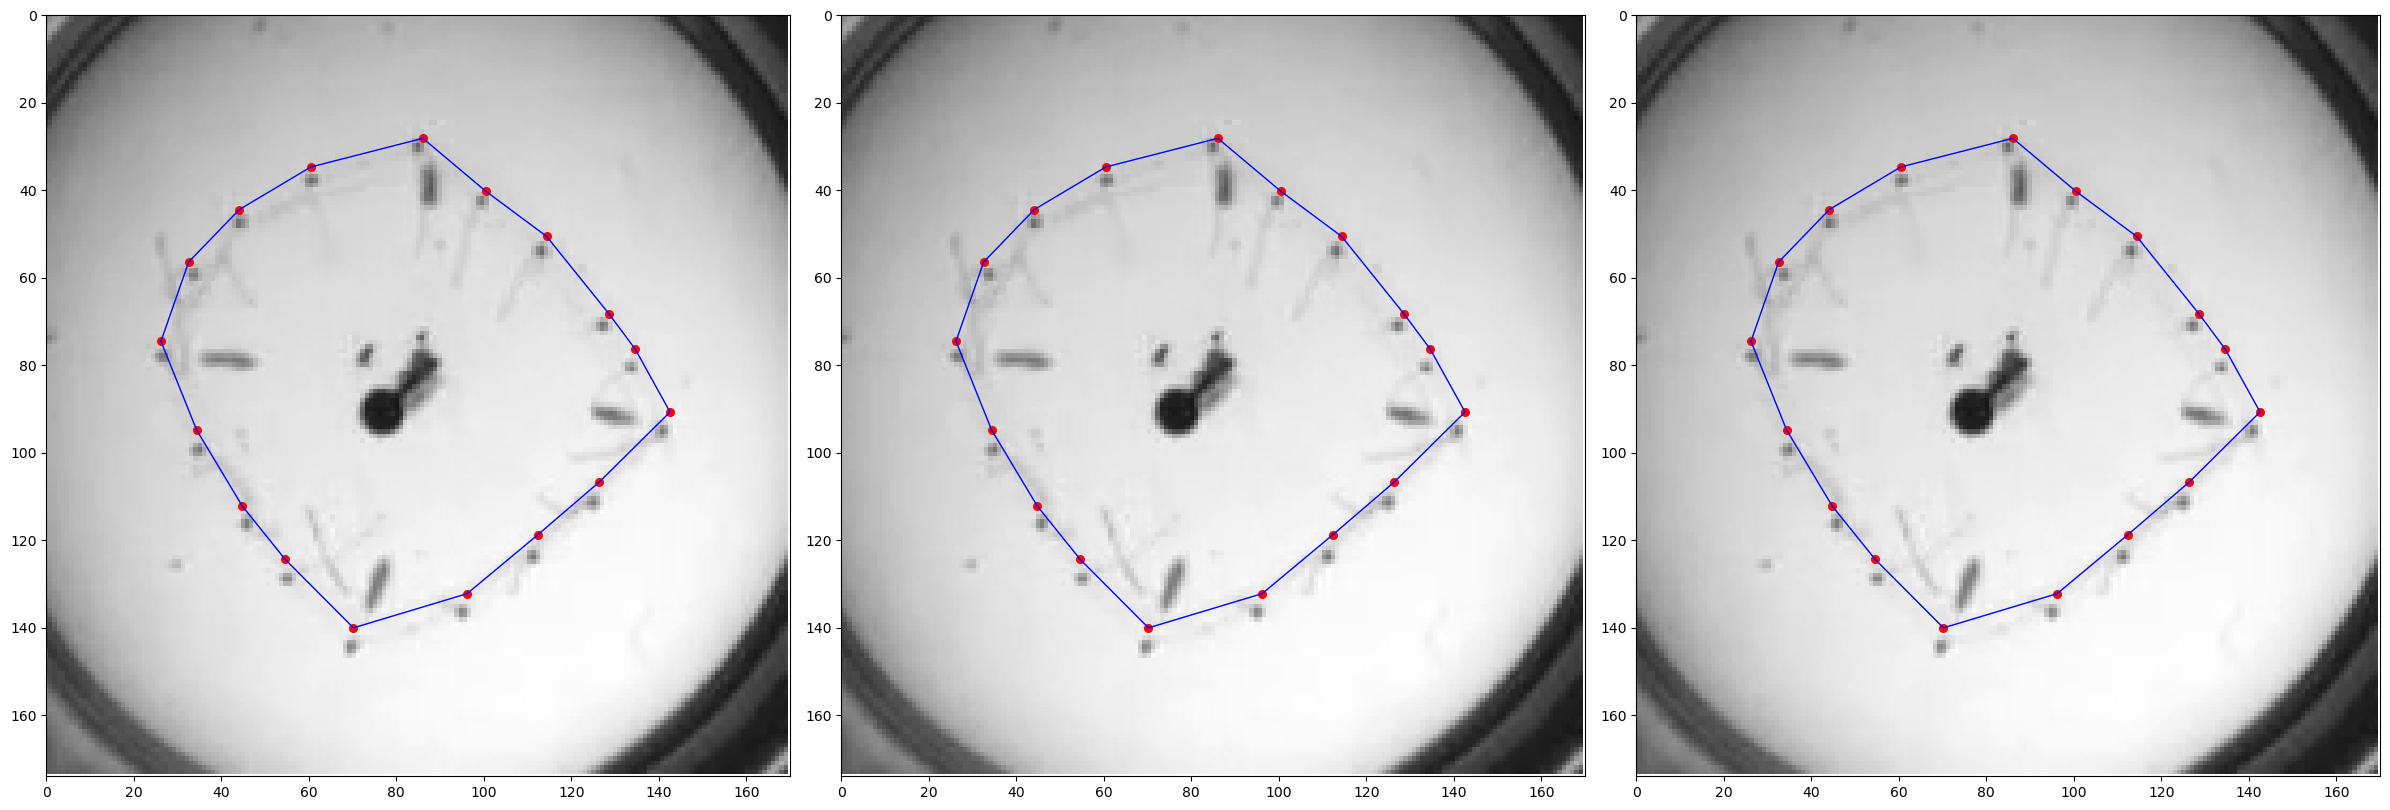

In [20]:
corrected_animation_path = '/home/mingxiao/Desktop/animation/c3_poly_corrected.mp4'
frame_cnt, x, y = labels_to_correct.video.shape[:3]
get_animation_from_tracked_points(all_corrected_coords, x, y, 
                                  output_path=corrected_animation_path, 
                                  bg_video=labels_to_correct.video, 
                                  bg_video_start_idx=1)

In [22]:
t10min_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/flowmax-tracking/reencoded_10min_t2.slp'
t10min_labels = sleap.load_file(t10min_path)
print(t10min_labels)

Labels(labeled_frames=90003, videos=1, skeletons=1, tracks=18)


### Round 3: 10-min video correction

In [24]:
methods = [(f'poly_{i}', eval(f'poly_{i}')) for i in range(1, 4)]
all_corrected_coords_r3 = []

for name, method in methods:
    start_time = time.time()
    corrected_coords = polygon_correction(t10min_labels, method, mins_score=0.4)
    end_time = time.time()
    all_corrected_coords_r3.append(corrected_coords)
    print(f"===== {name} execution time: {end_time - start_time:.2f} seconds ======\n")

all_tracked_points shape: (90002, 17, 2)
Missing point count: 126571
reorder_idx.shape: (17,)
===== poly_1 execution time: 107.94 seconds ======

all_tracked_points shape: (90002, 17, 2)
Missing point count: 126571
reorder_idx.shape: (17,)
===== poly_2 execution time: 1799.30 seconds ======

all_tracked_points shape: (90002, 17, 2)
Missing point count: 126571
reorder_idx.shape: (17,)
===== poly_3 execution time: 327.93 seconds ======



INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 2400x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/poly_corrected_10min.mp4
Animation saved to /home/mingxiao/Desktop/animation/poly_corrected_10min.mp4


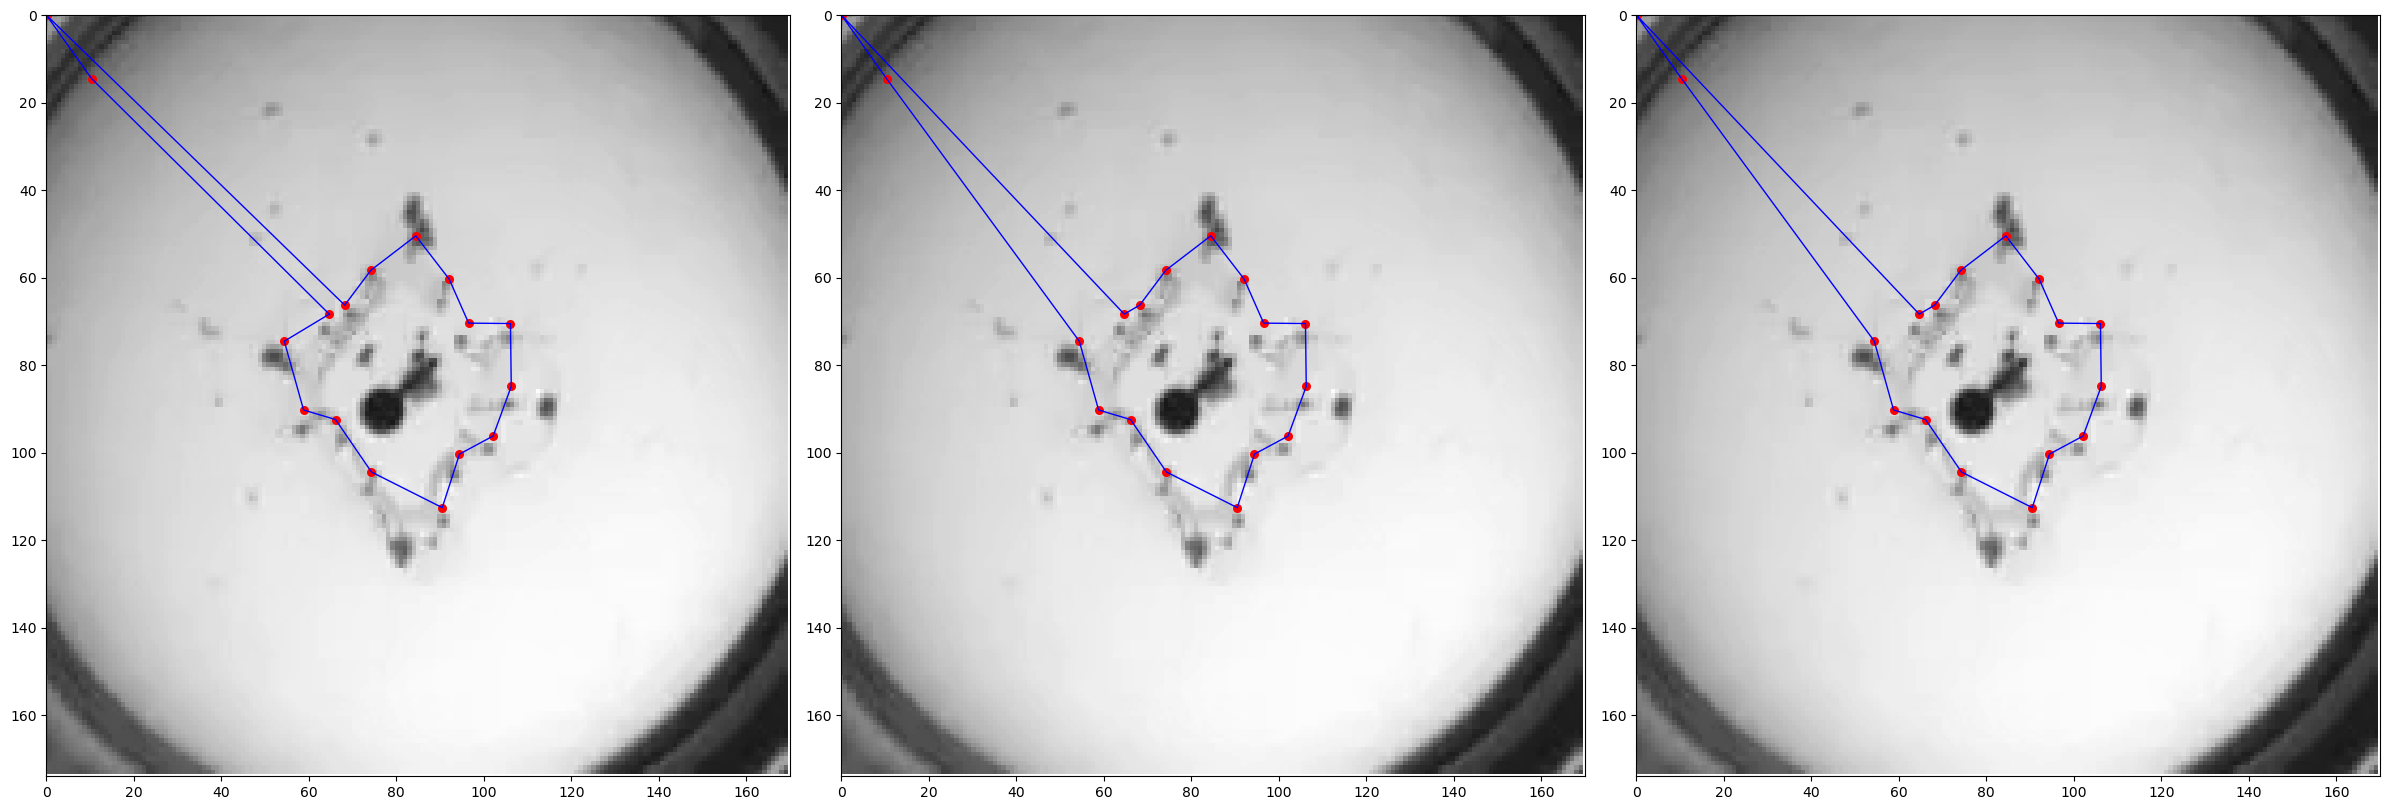

In [33]:
corrected_animation_path = '/home/mingxiao/Desktop/animation/poly_corrected_10min.mp4'
frame_cnt, x, y = t10min_labels.video.shape[:3]
get_animation_from_tracked_points(all_corrected_coords_r3, x, y, 
                                  output_path=corrected_animation_path, 
                                  bg_video=t10min_labels.video,
                                  bg_video_start_idx=1)

### Round 4: 10-min video correction (better tracking)

In [6]:
reencoded_10min_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/flowmax-tracking/reencoded_10min_t3.slp'
reencoded_10min_labels = sleap.load_file(reencoded_10min_path)
print(reencoded_10min_labels)

Labels(labeled_frames=90003, videos=1, skeletons=1, tracks=18)


In [7]:
methods = [(f'poly_{i}', eval(f'poly_{i}')) for i in range(1, 4)]
all_corrected_coords_r4 = []

for name, method in methods:
    start_time = time.time()
    corrected_coords = polygon_correction(reencoded_10min_labels, method, mins_score=0.4)
    end_time = time.time()
    all_corrected_coords_r4.append(corrected_coords)
    print(f"===== {name} execution time: {end_time - start_time:.2f} seconds ======\n")

all_tracked_points shape: (90002, 17, 2)
Missing point count: 126533
reorder_idx.shape: (17,)
===== poly_1 execution time: 107.31 seconds ======

all_tracked_points shape: (90002, 17, 2)
Missing point count: 126533
reorder_idx.shape: (17,)
===== poly_2 execution time: 1679.95 seconds ======

all_tracked_points shape: (90002, 17, 2)
Missing point count: 126533
reorder_idx.shape: (17,)
===== poly_3 execution time: 469.00 seconds ======



INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 2400x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/poly_corrected_10min_t3.mp4
Animation saved to /home/mingxiao/Desktop/animation/poly_corrected_10min_t3.mp4


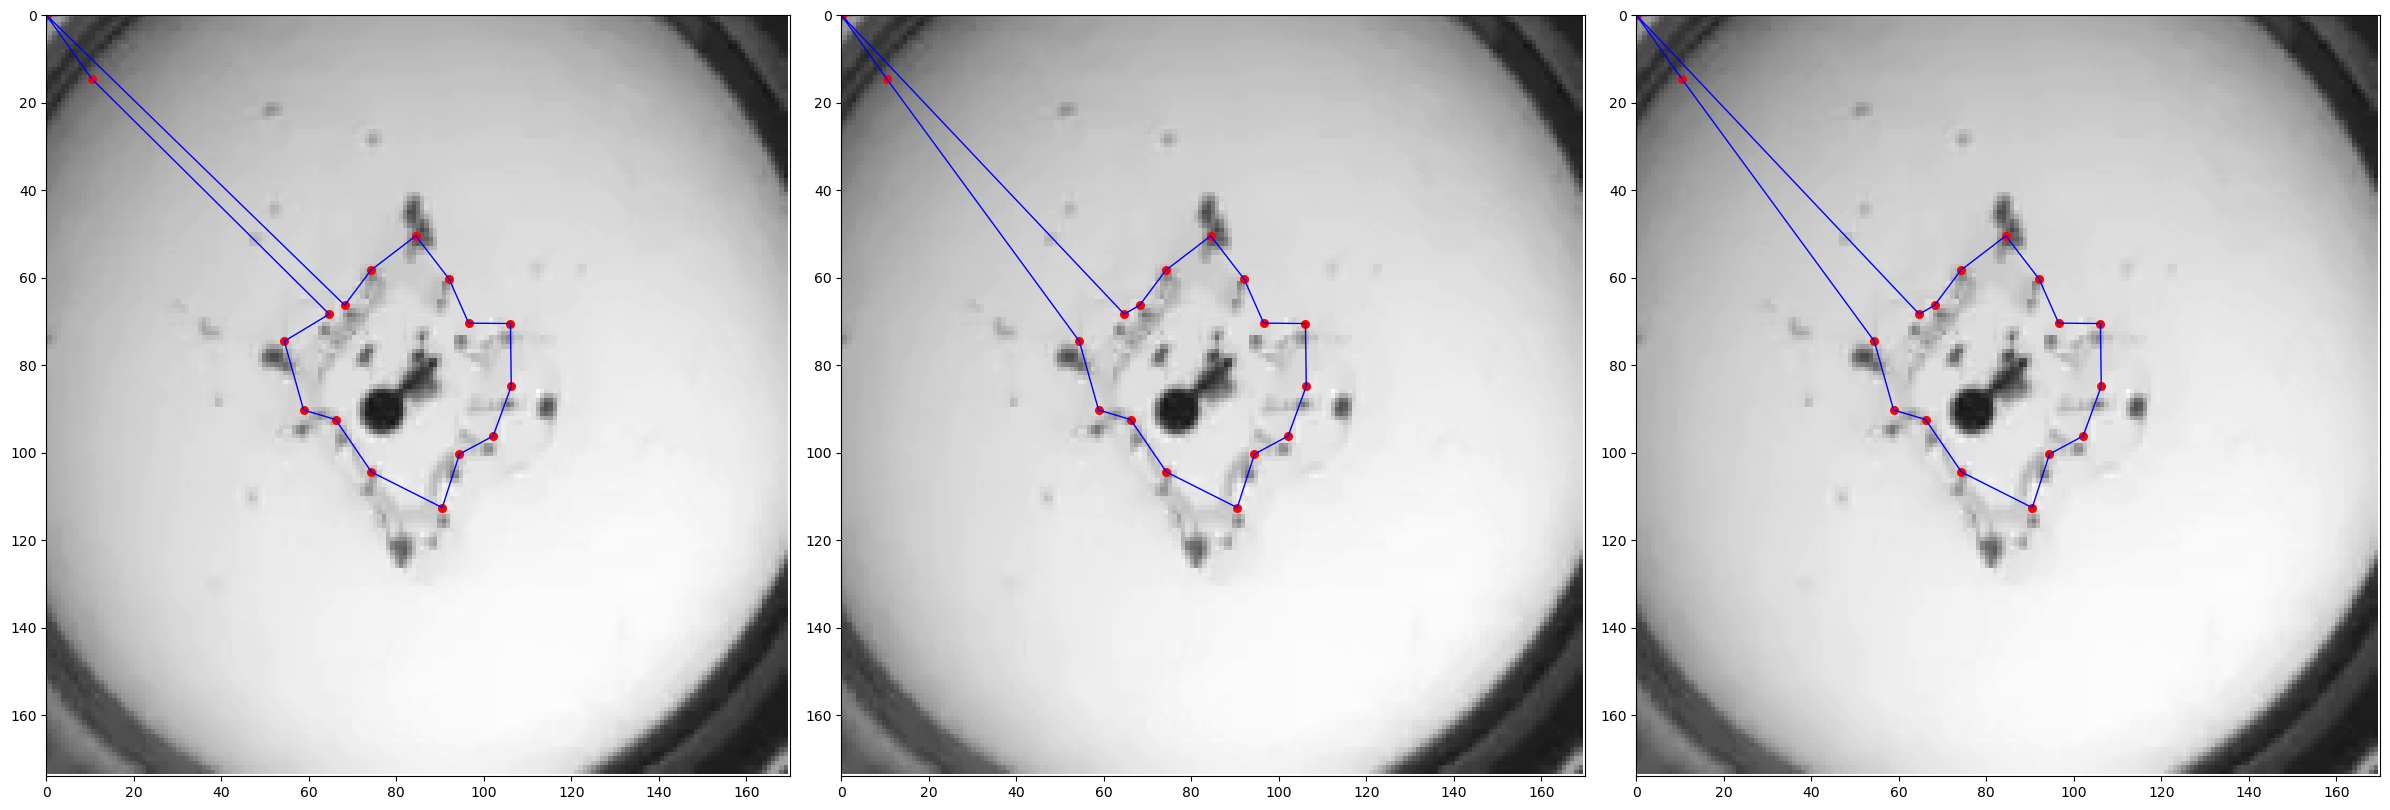

In [8]:
corrected_animation_path = '/home/mingxiao/Desktop/animation/poly_corrected_10min_t3.mp4'
frame_cnt, x, y = reencoded_10min_labels.video.shape[:3]
get_animation_from_tracked_points(all_corrected_coords_r4, x, y, 
                                  output_path=corrected_animation_path, 
                                  bg_video=reencoded_10min_labels.video,
                                  bg_video_start_idx=1)